In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
customers=pd.read_parquet('../limpios/olist_customers.parquet')
geolocation=pd.read_parquet('../limpios/olist_geolocation.parquet')
order_items=pd.read_parquet('../limpios/olist_orders_items.parquet')
order_payments=pd.read_parquet('../limpios/olist_order_payments.parquet')
order_reviews=pd.read_parquet('../limpios/olist_order_reviews.parquet')
orders=pd.read_parquet('../limpios/olist_orders.parquet')
products=pd.read_parquet('../limpios/olist_products.parquet')
sellers=pd.read_parquet('../limpios/olist_sellers.parquet')
product_category_translation=pd.read_parquet('../limpios/product_category_translation.parquet')

Antes de unir tablas, eliminamos los distintos datos de latitud y longitud que aparecen por codigo postal quedandonos con solo una

In [3]:
geolocation=geolocation.drop_duplicates(subset=['zip_code_prefix'])

In [4]:
geolocation.head(15)

,zip_code_prefix,geolocation_lat,geolocation_lng,city,state
index,,,,,
0,1037,-23.545621,-46.639292,Sao Paulo,SP
1,1046,-23.546081,-46.644820,Sao Paulo,SP
3,1041,-23.544392,-46.639499,Sao Paulo,SP
4,1035,-23.541578,-46.641607,Sao Paulo,SP
5,1012,-23.547762,-46.635361,São Paulo,SP
6,1047,-23.546273,-46.641225,Sao Paulo,SP
7,1013,-23.546923,-46.634264,Sao Paulo,SP
8,1029,-23.543769,-46.634278,Sao Paulo,SP
9,1011,-23.547640,-46.636032,Sao Paulo,SP


In [5]:
geolocation.duplicated().sum()

np.int64(0)

In [6]:
geolocation.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19015 entries, 0 to 999846
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   zip_code_prefix  19015 non-null  int64  
 1   geolocation_lat  19015 non-null  float64
 2   geolocation_lng  19015 non-null  float64
 3   city             19015 non-null  object 
 4   state            19015 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 891.3+ KB


Como en los codigos postales, También nos aseguramos que no haya multiples reviews para un pedido, quedandonos con la última si esto ocurre

In [7]:
order_reviews['order_id'].is_unique

False

In [8]:
order_reviews=order_reviews.drop_duplicates(subset=['order_id'], keep='last')

In [9]:
order_reviews.duplicated().sum()

np.int64(0)

#### Unimos las tablas en una sola

Order de union de tablas:

1. Unimos orders con items: orders_items --> orders, order_items, on= order_id, how= left

2. Unimos con products: product_orders_items ---> orders_items, productos, on= product_id, how= left

3. Unimos con customers: product_orders_items_customers ---> product_orders_items, customers, on=customer_id, how=left

4. Unimos con vendedores: product_orders_items_customers_sellers ----> product_orders_items_customers, sellers on = seller_id, how= left

5. Unimos con geolocation: product_orders_items_customers_sellers_location ---> product_orders_items_customers_sellers, geolocation on= zip_code_prefix, how=left

6. Unimos con reviews: olist_full_table ---> product_orders_items_customers_sellers_location, reviews on =order_id, how=left

In [10]:
orders_items= pd.merge(orders, order_items, on='order_id', how='left')

In [11]:
product_orders_items= pd.merge(orders_items, products, on='product_id', how ='left')

In [12]:
products_orders_items_customers= pd.merge (product_orders_items, customers, on='customer_id', how='left')

In [13]:
products_orders_items_customers_sellers= pd.merge (products_orders_items_customers, sellers, on='seller_id', how='left')

In [14]:
geolocation.head(2)

,zip_code_prefix,geolocation_lat,geolocation_lng,city,state
index,,,,,
0,1037,-23.545621,-46.639292,Sao Paulo,SP
1,1046,-23.546081,-46.644820,Sao Paulo,SP


In [15]:
products_orders_items_customers_sellers.head(2)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_length_cm,product_height_cm,product_width_cm,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,...,19.0,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,Sao Paulo,SP,9350.0,Maua,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.0,595fac2a385ac33a80bd5114aec74eb8,...,19.0,13.0,19.0,af07308b275d755c9edb36a90c618231,47813,Barreiras,BA,31570.0,Belo Horizonte,SP


In [16]:
products_orders_items_customers_sellers_custlocation= pd.merge (products_orders_items_customers_sellers, geolocation, left_on='customer_zip_code_prefix', right_on='zip_code_prefix', how='left')

In [17]:

products_orders_items_customers_sellers_selllocation= pd.merge (products_orders_items_customers_sellers_custlocation, geolocation, left_on='seller_zip_code_prefix', right_on='zip_code_prefix', how='left')

In [18]:
products_orders_items_customers_sellers_selllocation.head(2)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,zip_code_prefix_x,geolocation_lat_x,geolocation_lng_x,city_x,state_x,zip_code_prefix_y,geolocation_lat_y,geolocation_lng_y,city_y,state_y
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,...,3149.0,-23.574809,-46.587471,Sao Paulo,SP,9350.0,-23.680114,-46.452454,Maua,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.0,595fac2a385ac33a80bd5114aec74eb8,...,47813.0,-12.169860,-44.988369,Barreiras,BA,31570.0,-19.810119,-43.984727,Belo Horizonte,MG


In [19]:
products_orders_items_customers_sellers_selllocation= products_orders_items_customers_sellers_selllocation.rename (columns={'zip_code_prefix_x': 'customer_zip_code_prefix','geolocation_lat_x':'customer_geolocation_lat', 'geolocation_lng_x':'customer_geolocation_lng', 'city_x': 'customer_city', 'state_x':'customer_state', 'zip_code_prefix_y': 'seller_zip_code_prefix', 'geolocation_lat_y': 'seller_geolocation_lat','geolocation_lng_y': 'seller_geolocation_lng', 'city_y': 'seller_city', 'state_y': 'seller_state'})
pd.set_option('display.max_columns', None)
products_orders_items_customers_sellers_selllocation.sample(2)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,seller_zip_code_prefix,seller_city,seller_state,customer_zip_code_prefix,customer_geolocation_lat,customer_geolocation_lng,customer_city,customer_state,seller_zip_code_prefix,seller_geolocation_lat,seller_geolocation_lng,seller_city,seller_state
56363,bfa6db3b1ea85796d80dabdfd83b9d40,c11fa7875b229cc8087f67a0c3bfa230,delivered,2018-07-03 14:01:13,2018-07-05 16:20:09,2018-07-05 14:59:00,2018-07-09 21:11:58,2018-07-25,1.0,8aad7a3c7032428e9990ecccaf5e0543,d91fb3b7d041e83b64a00a3edfb37e4f,2018-07-09 14:31:27,117.60,18.92,Eletrodomesticos,60.0,392.0,1.0,200.0,27.0,13.0,17.0,6b50a1ad7d48096bd0e9d25879a17817,36015,Juiz De Fora,MG,11704.0,Praia Grande,SP,36015.0,-21.759649,-43.353198,Juiz De Fora,MG,11704.0,-24.026787,-46.493049,Praia Grande,SP
31006,5558c376f5604bb25823f2be7d1bc82c,0cc62071a707339f524e9c9520dd9b02,delivered,2018-04-09 14:21:15,2018-04-09 14:31:33,2018-04-11 19:46:35,2018-04-13 20:32:24,2018-04-23,1.0,3f14d740544f37ece8a9e7bc8349797e,6973a06f484aacf400ece213dbf3d946,2018-04-16 14:31:19,84.89,7.94,Informatica Acessorios,44.0,655.0,1.0,321.0,19.0,14.0,13.0,72f23703c5643b1ee93e42994e95a732,4304,Sao Paulo,SP,12230.0,Sao Jose Dos Campos,SP,4304.0,-23.626101,-46.631962,Sao Paulo,SP,12230.0,-23.221431,-45.888164,Sao Jose Dos Campos,SP


In [20]:
products_orders_items_customers_sellers_selllocation_categorytranslated= pd.merge(products_orders_items_customers_sellers_selllocation, product_category_translation, on='product_category_name', how='left')

In [21]:
olist_full_table= pd.merge (products_orders_items_customers_sellers_selllocation_categorytranslated, order_reviews, on='order_id', how='left')

In [22]:
olist_full_table.info()

#Columnas duplicadas al unir geolocation. Eliminarlas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 46 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       113425 non-null  object        
 1   customer_id                    113425 non-null  object        
 2   order_status                   113425 non-null  object        
 3   order_purchase_timestamp       113425 non-null  datetime64[ns]
 4   order_approved_at              113264 non-null  datetime64[ns]
 5   order_delivered_carrier_date   111457 non-null  datetime64[ns]
 6   order_delivered_customer_date  110196 non-null  datetime64[ns]
 7   order_estimated_delivery_date  113425 non-null  datetime64[ns]
 8   order_item_id                  112650 non-null  float64       
 9   product_id                     112650 non-null  object        
 10  seller_id                      112650 non-null  object        
 11  

In [23]:
olist_full_table_clean = olist_full_table.loc[:, ~olist_full_table.columns.duplicated()]

In [24]:
olist_full_table_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       113425 non-null  object        
 1   customer_id                    113425 non-null  object        
 2   order_status                   113425 non-null  object        
 3   order_purchase_timestamp       113425 non-null  datetime64[ns]
 4   order_approved_at              113264 non-null  datetime64[ns]
 5   order_delivered_carrier_date   111457 non-null  datetime64[ns]
 6   order_delivered_customer_date  110196 non-null  datetime64[ns]
 7   order_estimated_delivery_date  113425 non-null  datetime64[ns]
 8   order_item_id                  112650 non-null  float64       
 9   product_id                     112650 non-null  object        
 10  seller_id                      112650 non-null  object        
 11  

### Analisis principal

In [25]:
olist_full_table_clean.sample(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,seller_zip_code_prefix,seller_city,seller_state,customer_geolocation_lat,customer_geolocation_lng,seller_geolocation_lat,seller_geolocation_lng,product_category_name_english,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
102605,6ff688a972f3aed0188ccd2e29734c9a,cb0ff3021c7b4f63e2e80cb116569537,delivered,2018-03-26 15:50:00,2018-03-26 16:08:22,2018-03-27 17:31:41,2018-04-02 21:33:21,2018-04-17,1.0,bb7e168a9be3d6ead7cfdc295a63864d,a3a38f4affed601eb87a97788c949667,2018-03-30 16:08:22,59.90,19.39,Brinquedos,49.0,893.0,1.0,725.0,50.0,5.0,50.0,805a17599708b81dfde688fbfd108029,97610,Sao Francisco De Assis,RS,89204.0,Joinville,SC,-29.549583,-55.127555,-26.283149,-48.851285,Toys,ce5506a3d7ec72f7bc4791b5d3b0f26e,4.0,None,"Chegou no prazo, produto de boa qualidade. \r\n",2018-04-03,2018-04-04 13:11:28
14423,ea10db65e0559d69b56effcfed6a41c1,2c3bd36048f62f4a89633435b5e2a094,delivered,2017-12-04 08:24:13,2017-12-06 02:35:46,2017-12-06 21:48:57,2017-12-18 15:52:52,2017-12-28,1.0,90f97298579cd20412fdcc9b7a2d4b6b,a3dd39f583bc80bd8c5901c95878921e,2017-12-12 02:35:46,119.90,23.16,Alimentos Bebidas,31.0,502.0,1.0,475.0,20.0,16.0,13.0,eb6498bc3ebfad8980c0e5a34a996a46,6786,Taboao Da Serra,SP,41342.0,Salvador,BA,-23.622131,-46.808378,-12.901859,-38.404765,Food Drink,60d2600cf37f9a2e11ab2a9d8530237a,5.0,None,None,2017-12-19,2017-12-20 09:20:03
39269,1ed9a7f3d298570629e4d027458f4d49,98c3d3ba07fd808cfab5296bcdf5e2c7,delivered,2017-09-21 13:07:21,2017-09-23 02:25:54,2017-09-25 14:04:34,2017-10-07 14:28:34,2017-10-24,1.0,5cf189f48af24c605a16bcdb701df823,4a3ca9315b744ce9f8e9374361493884,2017-09-28 02:25:54,65.90,16.22,Cama Mesa Banho,46.0,556.0,1.0,750.0,45.0,15.0,35.0,6521cfec2db9b6d19e18560b5feb9648,99700,Erechim,RS,14940.0,Ibitinga,SP,-27.634768,-52.280294,-21.766477,-48.831547,Bed Bath Table,3d91aeffc852ede0dccdc5418b831b4c,3.0,None,None,2017-10-08,2017-10-10 10:57:46
87391,402ea461fe6e548240f694aaf551c069,eef238ea4577afeb9aa4a5e5082cd922,delivered,2018-05-10 19:34:21,2018-05-10 19:51:07,2018-05-11 13:39:00,2018-05-21 10:26:34,2018-05-29,1.0,540362999eae1bdce87657c3cc633805,b18871c324516afa228a13e8f1ef0ae9,2018-05-14 19:51:07,59.00,18.29,Ferramentas Jardim,23.0,605.0,2.0,700.0,30.0,23.0,20.0,cabfc37c65b42f1ce5a26ac21a7b7887,23970,Paraty,RJ,4186.0,Sao Paulo,SP,-23.226943,-44.726172,-23.652816,-46.599410,Garden Tools,b951471e5994b3d65c0cc5fb47aea0b1,5.0,10,None,2018-05-22,2018-05-23 01:22:15
23772,a8db6b84057a7a3a8a38968f10853069,bc9954bc4eb2a6fb6ed4eee63bbe2193,delivered,2017-06-15 14:38:02,2017-06-15 14:45:16,2017-06-20 14:22:03,2017-06-26 10:27:25,2017-07-06,3.0,8cba6b5fd208416dd934839f74f568e3,d1c281d3ae149232351cd8c8cc885f0d,2017-06-21 14:45:16,36.99,11.85,Cama Mesa Banho,57.0,95.0,1.0,500.0,20.0,10.0,15.0,b09f1bff1aff13c997af071602bc048b,3755,Sao Paulo,SP,14940.0,Ibitinga,SP,-23.509995,-46.502434,-21.766477,-48.831547,Bed Bath Table,f3b4c0f29e58c71d20f64876f5099617,5.0,None,None,2017-06-27,2017-06-27 19:29:43
34164,e7bf6c078fcd0eac3b977d498537e2b3,1ef155243064f7c445c0d8bfaec8e12d,delivered,2017-05-05 13:48:02,2017-05-06 02:25:24,2017-05-09 16:47:46,2017-05-15 18:26:13,2017-05-30,1.0,1ac8f5283525f67f04345f07c167ba80,3340ef1913fb70d28420f6ceb685c339,2017-05-11 02:25:24,299.90,17.31,Informatica Acessorios,45.0,165.0,1.0,850.0,36.0,21.0,21.0,b7f82a696d98c03d1e804050568a99f5,12070,Taubate,SP,87040.0,Maringa,PR,-23.024288,-45.540830,-23.413822,-51.907774,Computers Accessories,d0c2b9d96c387604a96ae43e7126cf9b,4.0,None,foi bom,2

### Comprobamos nulos tras unir las tablas

In [26]:
(olist_full_table_clean.isnull().sum() / len(olist_full_table_clean)) * 100

order_id                          0.000000
customer_id                       0.000000
order_status                      0.000000
order_purchase_timestamp          0.000000
order_approved_at                 0.141944
order_delivered_carrier_date      1.735067
order_delivered_customer_date     2.846815
order_estimated_delivery_date     0.000000
order_item_id                     0.683271
product_id                        0.683271
seller_id                         0.683271
shipping_limit_date               0.683271
price                             0.683271
freight_value                     0.683271
product_category_name             2.097421
product_name_lenght               2.097421
product_description_lenght        2.097421
product_photos_qty                2.097421
product_weight_g                  2.097421
product_length_cm                 2.097421
product_height_cm                 2.097421
product_width_cm                  2.097421
customer_unique_id                0.000000
customer_zi

### Análisis principal

-Unos tres años compras en la tabla. Primer pedido: 2016-09-04. Último pedido: 2018-10-17

-Precio (grandes fluctuaciones con outliers y una alta desvacióne standar): de media son 120 dolares brasileños por pedidos, pero es mas exacto usar la mediana, quedando este en casi 75 (74,99). El pedido mas caro ha sido de 6735, el mas barato de 0,85

-Reviews: Media de puntuaciones de 4 (sobre 5). Aunque hay algunas reviews malas con puntuacion de 1, alrededor del 75% son de 4 y 5, con el 50% siendo la mas alta.

-La mayoria de los clientes no escriben en sus reviews y solamente puntúan. De todos los pedidos realizados, el 88% no tiene titulo de comentario y un 57,7% no dejan ningún mensaje.

-Tenemos más de 99.4k pedidos unicos totales (ventas) de 32951 productos alrededor de 73 categorias, procedentes de +3k vendedores. En estos años hemos conseguido un total de 13.591.643,7 dolares brasileños de ingresos.


In [27]:
olist_full_table_clean.describe().T

,count,mean,min,25%,50%,75%,max,std
order_purchase_timestamp,113425,2017-12-31 12:25:41.686480128,2016-09-04 21:15:19,2017-09-13 11:05:49,2018-01-19 10:37:45,2018-05-04 14:22:16,2018-10-17 17:30:18,NaN
order_approved_at,113264,2017-12-31 22:40:56.664121088,2016-09-15 12:16:38,2017-09-13 20:25:10.500000,2018-01-19 16:59:52.500000,2018-05-04 18:31:38.500000,2018-09-03 17:40:06,NaN
order_delivered_carrier_date,111457,2018-01-05 02:17:27.942515968,2016-10-08 10:34:01,2017-09-18 20:37:00,2018-01-24 18:44:33,2018-05-08 13:20:00,2018-09-11 19:48:28,NaN
order_delivered_customer_date,110196,2018-01-14 13:25:24.023939328,2016-10-11 13:46:32,2017-09-26 20:09:44.500000,2018-02-02 20:57:23,2018-05-15 20:09:21.500000,2018-10-17 13:22:46,NaN
order_estimated_delivery_date,113425,2018-01-24 08:22:34.875909120,2016-09-30 00:00:00,2017-10-04 00:00:00,2018-02-15 00:00:00,2018-05-25 00:00:00,2018-11-12 00:00:00,NaN
order_item_id,112650.0,1.197834,1.0,1.0,1.0,1.0,21.0,0.705124
shipping_limit_date,112650,2018-01-07 15:36:52.192685312,2016-09-19 00:15:34,2017-09-20 20:57:27.500000,2018-01-26 13:59:35,2018-05-10 14:34:00.750000128,2020-04-09 22:35:08,NaN
price,112650.0,120.653739,0.85,39.9,74.99,134.9,6735.0,183.633928
freight_value,112650.0,19.99032,0.0,13.08,16.26,21.15,409.68,15.806405
product_name_lenght,111046.0,48.775877,5.0,42.0,52.0,57.0,76.0,10.02557


In [28]:
olist_full_table_clean['price'].median()

np.float64(74.99)

In [29]:
olist_full_table_clean['review_score'].value_counts()

review_score
5.0    63218
4.0    21234
1.0    14682
3.0     9423
2.0     3907
Name: count, dtype: int64

In [30]:
olist_full_table_clean['review_score'].value_counts(normalize=True) * 100

review_score
5.0    56.211766
4.0    18.880708
1.0    13.054844
3.0     8.378681
2.0     3.474001
Name: proportion, dtype: float64

In [31]:
56.211766 + 18.880708

75.092474

In [32]:
olist_full_table_clean['order_id'].nunique()

99441

In [33]:
olist_full_table_clean['product_category_name'].nunique()

73

In [34]:
olist_full_table_clean['seller_id'].nunique()

3095

In [35]:
olist_full_table_clean['product_id'].nunique()

32951

In [36]:
olist_full_table_clean['price'].sum()

np.float64(13591643.7)

## Categorias

### Creamos columna con días desde envio a entrega

In [37]:
olist_full_table_clean['actual_days_until_delivery'] = (olist_full_table_clean['order_delivered_customer_date'] - olist_full_table_clean['order_purchase_timestamp']).dt.days

C:\Users\Gordon\AppData\Local\Temp\ipykernel_35684\2009333165.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  olist_full_table_clean['actual_days_until_delivery'] = (olist_full_table_clean['order_delivered_customer_date'] - olist_full_table_clean['order_purchase_timestamp']).dt.days


In [38]:
olist_full_table_clean['estimated_days_until_delivery'] = (olist_full_table_clean['order_estimated_delivery_date'] - olist_full_table_clean['order_purchase_timestamp']).dt.days

C:\Users\Gordon\AppData\Local\Temp\ipykernel_35684\356605737.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  olist_full_table_clean['estimated_days_until_delivery'] = (olist_full_table_clean['order_estimated_delivery_date'] - olist_full_table_clean['order_purchase_timestamp']).dt.days


In [39]:
olist_full_table_clean['days_until_carrier_delivery'] =  (olist_full_table_clean['order_delivered_carrier_date'] - olist_full_table_clean['order_purchase_timestamp']).dt.days

C:\Users\Gordon\AppData\Local\Temp\ipykernel_35684\3380496971.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  olist_full_table_clean['days_until_carrier_delivery'] =  (olist_full_table_clean['order_delivered_carrier_date'] - olist_full_table_clean['order_purchase_timestamp']).dt.days


In [40]:
olist_full_table_clean['days_from_carrier_to_customer'] = (olist_full_table_clean['order_delivered_customer_date'] - olist_full_table_clean['order_delivered_carrier_date']).dt.days

C:\Users\Gordon\AppData\Local\Temp\ipykernel_35684\4185490686.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  olist_full_table_clean['days_from_carrier_to_customer'] = (olist_full_table_clean['order_delivered_customer_date'] - olist_full_table_clean['order_delivered_carrier_date']).dt.days


In [41]:
# Creamos columna para la diferencia entre el estimado y el real
olist_full_table_clean['difference_estimated_actual_delivery']= olist_full_table_clean['days_until_carrier_delivery'] - olist_full_table_clean['estimated_days_until_delivery']

C:\Users\Gordon\AppData\Local\Temp\ipykernel_35684\17499918.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  olist_full_table_clean['difference_estimated_actual_delivery']= olist_full_table_clean['days_until_carrier_delivery'] - olist_full_table_clean['estimated_days_until_delivery']


In [42]:
olist_full_table_clean.sample(2)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,seller_zip_code_prefix,seller_city,seller_state,customer_geolocation_lat,customer_geolocation_lng,seller_geolocation_lat,seller_geolocation_lng,product_category_name_english,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,actual_days_until_delivery,estimated_days_until_delivery,days_until_carrier_delivery,days_from_carrier_to_customer,difference_estimated_actual_delivery
110070,270044e25a104d6ab5daf7369e33779d,6cf048ee948a79b9d946243e1e05fcf1,delivered,2018-08-14 07:23:07,2018-08-15 03:23:59,2018-08-15 12:59:00,2018-08-16 11:15:42,2018-08-17,1.0,aa8d88eb4b9cb38894e33fa624c4287f,6560211a19b47992c3666cc44a7e94c0,2018-08-17 03:23:59,55.0,7.65,Relogios Presentes,54.0,335.0,4.0,250.0,16.0,2.0,11.0,e5d4f3b301959c88077a062efbe3ebf9,9781,Sao Bernardo Do Campo,SP,5849.0,Sao Paulo,SP,-23.727641,-46.531065,-23.651115,-46.755211,Watches Gifts,7af17ae7a6b7a42ed137109f09ea4309,4.0,Amei,Gostei muito do produto,2018-08-17,2018-08-19 23:14:54,2.0,2,1.0,0.0,-1.0
109265,ea97616a19d3b2683ab949def1037708,e01dd706e00cef25a6be635737bee134,delivered,2017-01-17 14:57:29,2017-01-17 15:10:17,2017-01-18 15:06:19,2017-01-26 13:57:31,2017-02-27,1.0,9123002e53f822415107f07e5dcf199f,6edacfd9f9074789dad6d62ba7950b9c,2017-01-21 14:57:29,66.9,15.68,Cool Stuff,53.0,177.0,3.0,625.0,30.0,19.0,22.0,c15e721e52209690f253a6c8fd1a17de,23045,Rio De Janeiro,RJ,7135.0,Guarulhos,SP,-22.915062,-43.552655,-23.422313,-46.520062,Cool Stuff,1f096111c0fd02263274a27e200baf6e,5.0,None,None,2017-01-27,2017-01-29 18:28:50,8.0,40,1.0,7.0,-39.0


### Creamos columna categoría para ver si ha habido retraso o no

In [43]:
def categorizacion_comparativa_entrega(fila):
    if pd.isna(fila['difference_estimated_actual_delivery']):
        return 'No data'
    elif fila['difference_estimated_actual_delivery'] == 0:
        return 'On time'
    elif fila['difference_estimated_actual_delivery'] < 0:
        return 'Early'
    else:
        return 'Delayed'

In [44]:
olist_full_table_clean['delivery_difference_category'] = olist_full_table_clean.apply(categorizacion_comparativa_entrega, axis=1)

In [45]:
olist_full_table_clean.sample(2)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,seller_zip_code_prefix,seller_city,seller_state,customer_geolocation_lat,customer_geolocation_lng,seller_geolocation_lat,seller_geolocation_lng,product_category_name_english,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,actual_days_until_delivery,estimated_days_until_delivery,days_until_carrier_delivery,days_from_carrier_to_customer,difference_estimated_actual_delivery,delivery_difference_category
79543,7a0ec92566b936a1e15fcf8b9f934f2c,24b168407182b01edc578f21c2dfb981,delivered,2018-05-11 18:54:55,2018-05-12 03:15:11,2018-05-29 07:07:00,2018-06-01 18:34:27,2018-06-18,1.0,8ed094bfe076c568f6bb10feada3f75d,7c67e1448b00f6e969d365cea6b010ab,2018-05-29 03:15:11,179.9,46.07,Moveis Escritorio,43.0,1128.0,1.0,16133.0,63.0,59.0,25.0,ff763f6fccce840a04aea139ec04c86c,40415,Salvador,BA,8577.0,Itaquaquecetuba,SP,-12.929005,-38.509855,-23.482623,-46.374490,Office Furniture,318313d855aec07516bbb4db64671e3c,5.0,Bom produto,None,2018-06-02,2018-06-04 21:45:44,20.0,37,17.0,3.0,-20.0,Early
60874,702ec26902de328ad2830835af529b0b,e8d469267909af4c76fa317649c3d860,delivered,2018-08-10 16:04:45,2018-08-10 16:25:15,2018-08-13 15:26:00,2018-08-14 18:46:49,2018-08-17,2.0,cc88837a83ef7b7ea2bf724434a53ef3,6bb62a4912377c7bfe7cb17b406bc7e6,2018-08-15 16:24:45,351.0,20.72,Construcao Ferramentas Seguranca,51.0,561.0,1.0,1150.0,80.0,7.0,11.0,ce6160651998b40db0a0f3b9d69f7f3d,9230,Santo Andre,SP,13215.0,Jundiai,SP,-23.615718,-46.531184,-23.175897,-46.886594,Construction Tools Safety,9bfaba3e468a462d5f6f2a6928e4b9f6,5.0,Recomendo,"Loja:Produto entregue com rapidez, processo ág...",2018-08-15,2018-08-19 14:05:46,4.0,6,2.0,1.0,-4.0,Early


### Creamos columna de rangos de peso en paquetes

In [46]:
categoria_peso=( 'Light(0-1kg)', 'Medium (1-5kg)', 'Heavy (5-10kg)', 'Very Heavy (+10kg)')
olist_full_table_clean['weight_category']=pd.cut(olist_full_table_clean['product_weight_g'], bins =[0,1000,5000,10000, np.inf], labels=categoria_peso)

### Creamos columna de rangos de precios

In [47]:
categoria_precios= ('Affordable (0-50)' , 'Standard (50-100)', 'Mid-Range (100-250)', 'Premium (250-500)', 'High-End (500-1000)', 'Luxury (+1000)')
olist_full_table_clean['price_category']=pd.cut(olist_full_table_clean['price'], bins=[0,50,100,250,500,1000, np.inf], labels=categoria_precios)

In [48]:
olist_full_table_clean.sample(2)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,seller_zip_code_prefix,seller_city,seller_state,customer_geolocation_lat,customer_geolocation_lng,seller_geolocation_lat,seller_geolocation_lng,product_category_name_english,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,actual_days_until_delivery,estimated_days_until_delivery,days_until_carrier_delivery,days_from_carrier_to_customer,difference_estimated_actual_delivery,delivery_difference_category,weight_category,price_category
46034,85f64d0cfe65f28d287067a0032a3b4c,36bafbf5ea6442ced7966411c8b9584f,delivered,2017-10-18 17:01:49,2017-10-19 10:46:06,2017-10-20 11:24:06,2017-11-15 15:38:50,2017-11-22,1.0,461f43be3bdf8844e65b62d9ac2c7a5a,4869f7a5dfa277a7dca6462dcf3b52b2,2017-10-27 10:46:06,146.0,34.82,Relogios Presentes,35.0,591.0,3.0,444.0,20.0,14.0,16.0,c859278ef3adb8e99be0e08765140f69,58052,Joao Pessoa,PB,14840.0,Guariba,SP,-7.157377,-34.832533,-21.362358,-48.232976,Watches Gifts,6fb035e1040a8fda893c036f4a61ec57,5.0,None,None,2017-11-16,2017-11-16 18:35:17,27.0,34,1.0,26.0,-33.0,Early,Light(0-1kg),Mid-Range (100-250)
101989,d681e67cbf0c8f6d2b67a6b6871d7f50,c38a80e0350ff3bb0771ef23799199c3,delivered,2017-03-28 08:58:30,2017-03-28 09:10:25,2017-03-29 12:08:23,2017-03-31 13:03:15,2017-04-17,1.0,f71973c922ccaab05514a36a8bc741b8,5dceca129747e92ff8ef7a997dc4f8ca,2017-04-03 09:10:25,109.9,24.05,Malas Acessorios,47.0,482.0,2.0,16100.0,35.0,65.0,44.0,b239b3d65726c187cdd7c52c94254db0,1227,Sao Paulo,SP,13450.0,Santa Barbara D´Oeste,SP,-23.537290,-46.654431,-22.760478,-47.412811,Luggage Accessories,e8938a51136a62c4a86efa745dca7a42,5.0,None,O produto muito bom gostei,2017-04-01,2017-04-04 10:26:13,3.0,19,1.0,2.0,-18.0,Early,Very Heavy (+10kg),Mid-Range (100-250)


###  Hay correlacion entre peso del paquete y tiempo de envío?

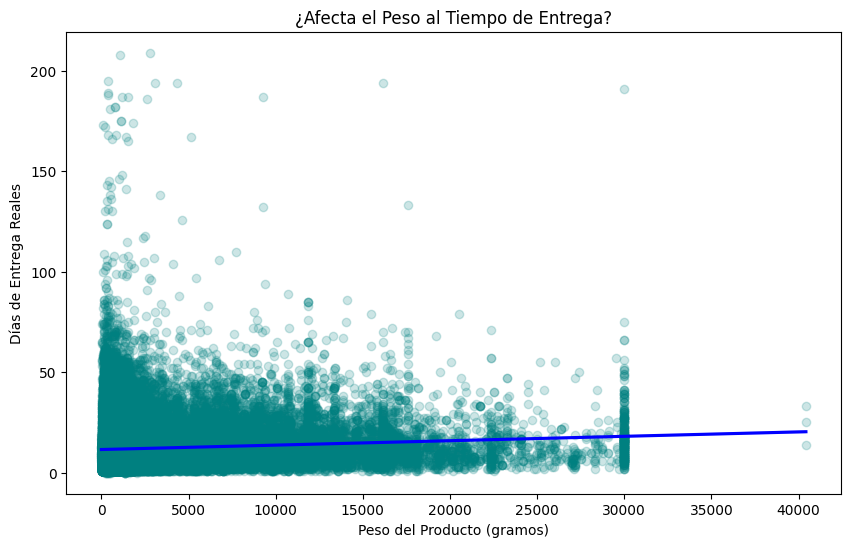

In [49]:
plt.figure(figsize=(10, 6))
sns.regplot(data=olist_full_table_clean, x='product_weight_g', y='actual_days_until_delivery', 
            scatter_kws={'alpha':0.2, 'color':'teal'}, line_kws={'color':'blue'})

plt.title('¿Afecta el Peso al Tiempo de Entrega?')
plt.xlabel('Peso del Producto (gramos)')
plt.ylabel('Días de Entrega Reales')
plt.show()

Relacion muy leve entre peso del producto y días de envio, sin que haya una diferencia siginificativa entre estos. EL peso no es un factor determinante si se producce un aumento del tiempo de entrega.

### ¿Afecta la region a la que se envía?

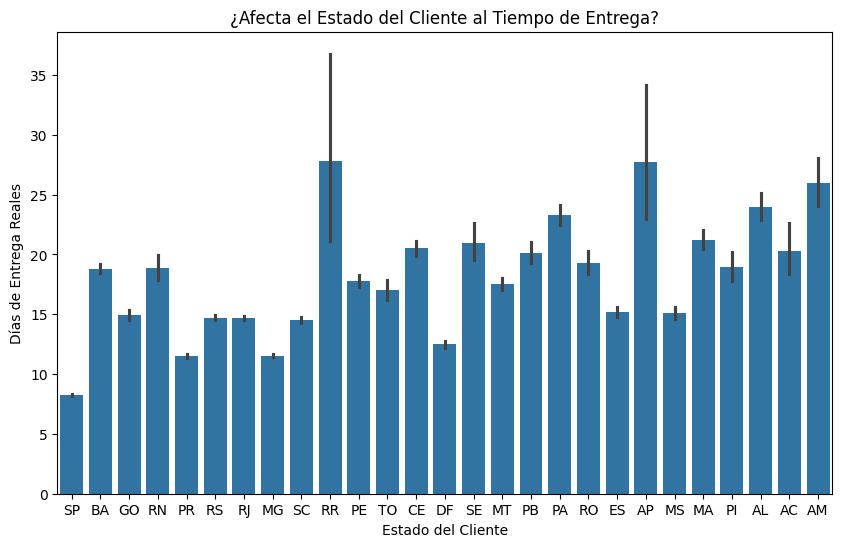

In [50]:
plt.figure(figsize=(10, 6))
sns.barplot(data=olist_full_table_clean, x='customer_state', y='actual_days_until_delivery')

plt.title('¿Afecta el Estado del Cliente al Tiempo de Entrega?')
plt.xlabel('Estado del Cliente')
plt.ylabel('Días de Entrega Reales')
plt.show()

Se ve una difefrencia entre algunos estados, con tres estados del norte teniendo mayores dias de entrega comparados con el resto (RR: roraima, AP: Amapá y AM: Amazonas), con entregas que se aproximan al mes de espera. Destaca la rapidez de los envios a Sao Paulo comparado con el resto, estando por debajo de los 10 días. Considerar mejorar la logística para que les llegue antes a esas regiones.

### ¿Son las reviews de los estados donde se tarda más en entregar menores?

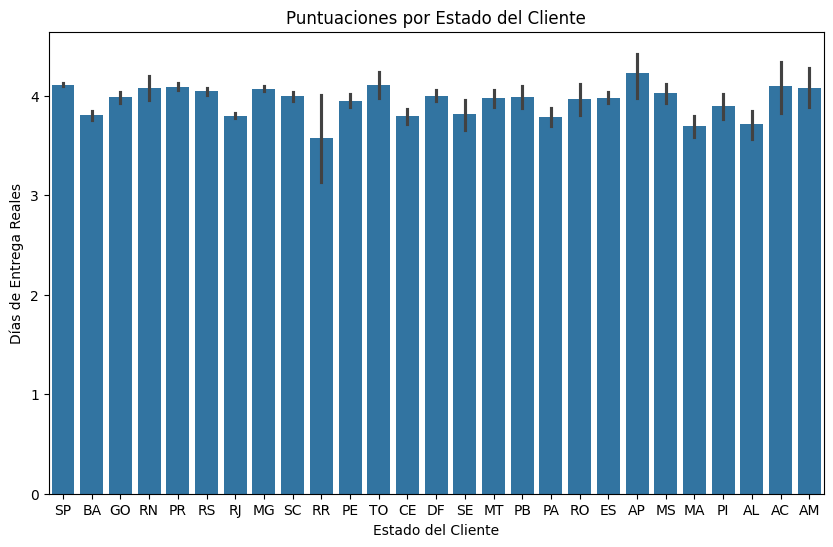

In [51]:
plt.figure(figsize=(10, 6))
sns.barplot(data=olist_full_table_clean, x='customer_state', y='review_score')

plt.title('Puntuaciones por Estado del Cliente')
plt.xlabel('Estado del Cliente')
plt.ylabel('Días de Entrega Reales')
plt.show()

Destaca una menor puntuacion en el estado de RR, pudiendo ser afectado por la entrega, mientras en los otros dos no es noticioso

### Afectan los vendedores a los plazos de entrega?

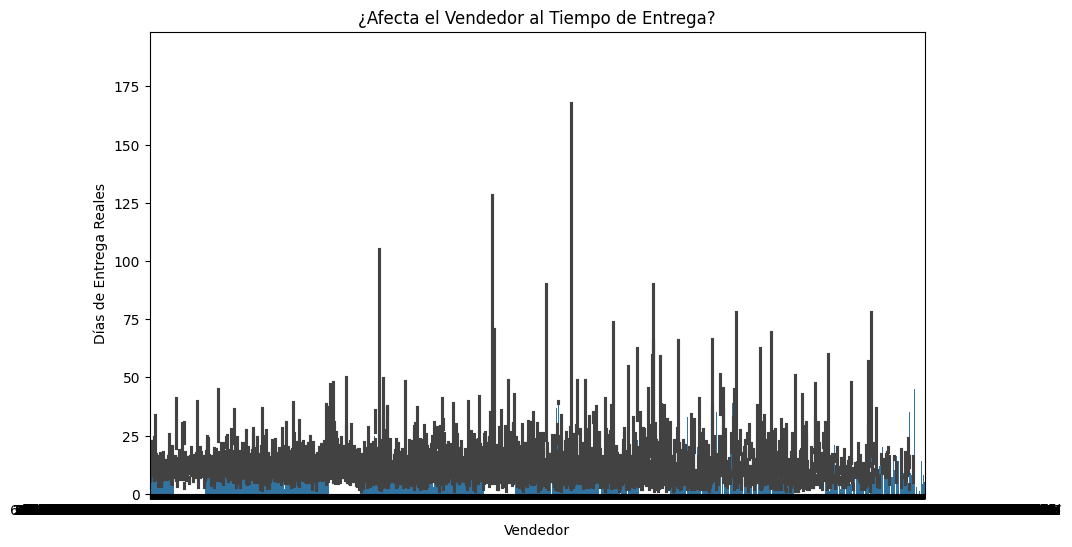

In [52]:
plt.figure(figsize=(10, 6))
sns.barplot(data=olist_full_table_clean, x='seller_id', y='actual_days_until_delivery')

plt.title('¿Afecta el Vendedor al Tiempo de Entrega?')
plt.xlabel('Vendedor')
plt.ylabel('Días de Entrega Reales')
plt.show()

Hay algunos vendedores que están muy por encima del resto en dias de entrega reales, extraemos los que más tardan

In [53]:
seller_analysis = olist_full_table_clean.groupby('seller_id').agg(
    avg_delivery_days=('actual_days_until_delivery', 'mean'),
    total_sales=('order_id', 'count')).reset_index()

seller_analysis = seller_analysis[seller_analysis['total_sales'] > 5]

In [54]:
seller_analysis = seller_analysis.sort_values('avg_delivery_days', ascending=False)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'eebb3372362aa9a46975164bed19a7e7'),
  Text(1, 0, '8c3b533c63cca56240f94f1e3a6b18ef'),
  Text(2, 0, '8d92f3ea807b89465643c219455e7369'),
  Text(3, 0, 'cb41bfbcbda0aea354a834ab222f9a59'),
  Text(4, 0, 'ecccfa2bb93b34a3bf033cc5d1dcdc69'),
  Text(5, 0, '6cf476a4ca74498db55cbccdaa9dcfb6'),
  Text(6, 0, 'c42fd8e4d47dfb18ce5222f2dd7752f9'),
  Text(7, 0, 'e83c76265fc54bf41eac728805e4da77'),
  Text(8, 0, '714b9a1332840f257b49f476bea4e341'),
  Text(9, 0, '66e0557ecc2b4dbea057e93f215f68d8')])

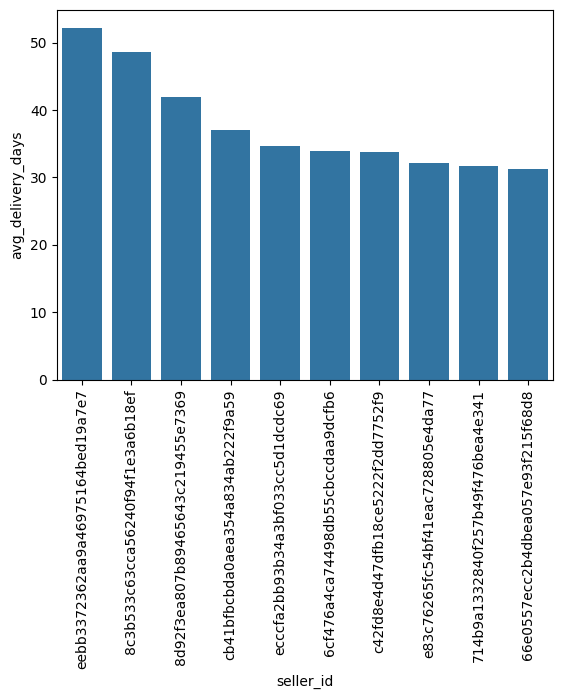

In [55]:
top_slow_sellers = seller_analysis.head(10)
sns.barplot(data=top_slow_sellers, x='seller_id', y='avg_delivery_days')
plt.xticks(rotation=90)

Hay 10 vendedores que tienen mas de 30 dias de proceso de envío real de media desde que se procesa la venta hasta que se entrega, tardando demasiado en  el proceso y afectando a la media de días de envio general. Se podria avisar a estos vendedores para que intenten reducir esta latencia.

### ¿Hay relacion entre precio de producto y su tardanza en la entrega?

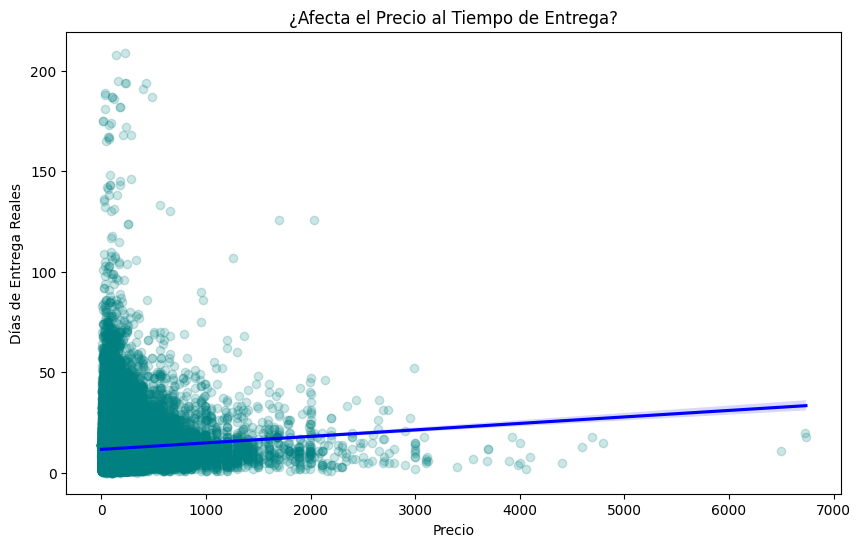

In [56]:
plt.figure(figsize=(10, 6))
sns.regplot(data=olist_full_table_clean, x='price', y='actual_days_until_delivery', 
            scatter_kws={'alpha':0.2, 'color':'teal'}, line_kws={'color':'blue'})

plt.title('¿Afecta el Precio al Tiempo de Entrega?')
plt.xlabel('Precio')
plt.ylabel('Días de Entrega Reales')
plt.show()

El precio no afecta a los tiempos de entrega, sin mayor tardanza en los productos baratos respecto a los caros y viceversa.

### ¿Hay relacion entre precio de producto y su puntuacion de review?

<Axes: xlabel='review_score', ylabel='price'>

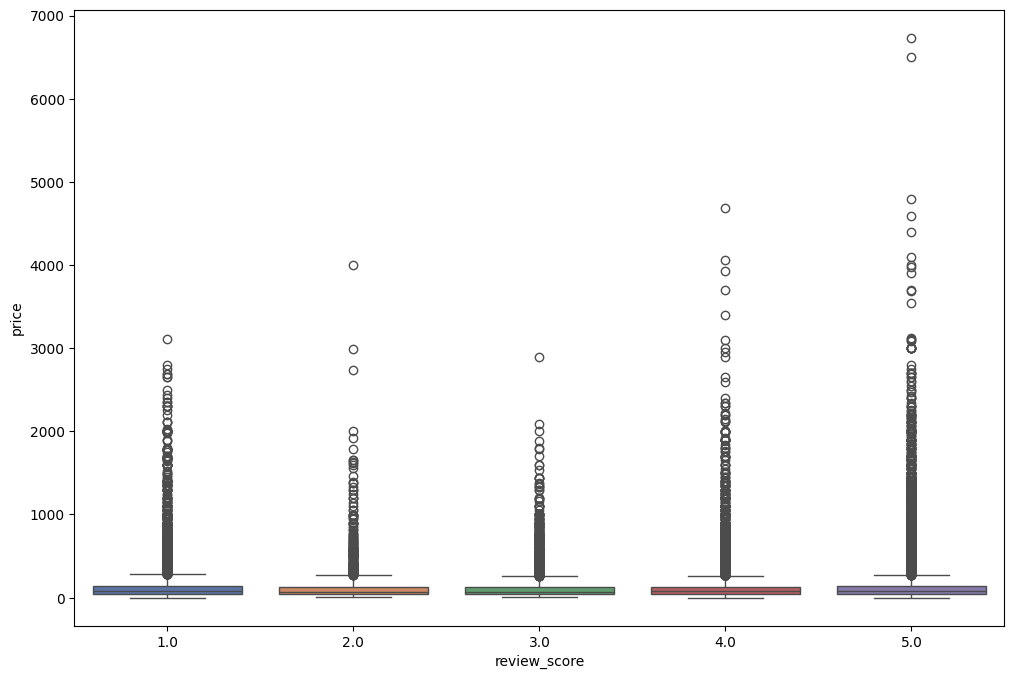

In [57]:
plt.figure(figsize=(12, 8))

sns.boxplot(data=olist_full_table, x='review_score', y='price', hue='review_score',palette='deep', legend=False)

No vemos una correlacion entre el precio y las reviews, ya que hay productos muy caros repartidos de forma similar en todas las puntuaciones. Hay usuarios con productos de lujo con experiencia de todas las puntuaciones y usuarios con productos baratos tambien repartidos de forma similar.

### Total ingresos por categoria

In [58]:
ingresos_por_categoria= olist_full_table_clean.groupby('product_category_name_english')['price'].sum()
ingresos_categoria_mayor_a_menor=ingresos_por_categoria.sort_values(ascending=False). head(20)

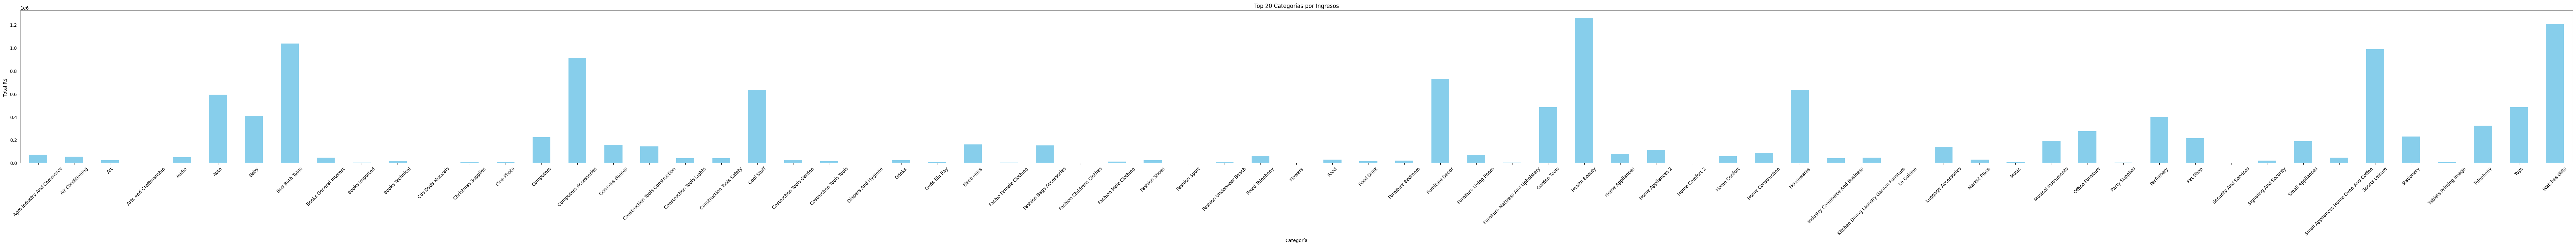

In [59]:
ingresos_por_categoria.plot(kind='bar', figsize=(100, 6), color='skyblue')
plt.title('Top 20 Categorías por Ingresos')
plt.ylabel('Total R$')
plt.xlabel('Categoría')
plt.xticks(rotation=45)
plt.show()

#### Al haber tantas categorias de producto, mejor centrarse en el top por volumen de ingresos

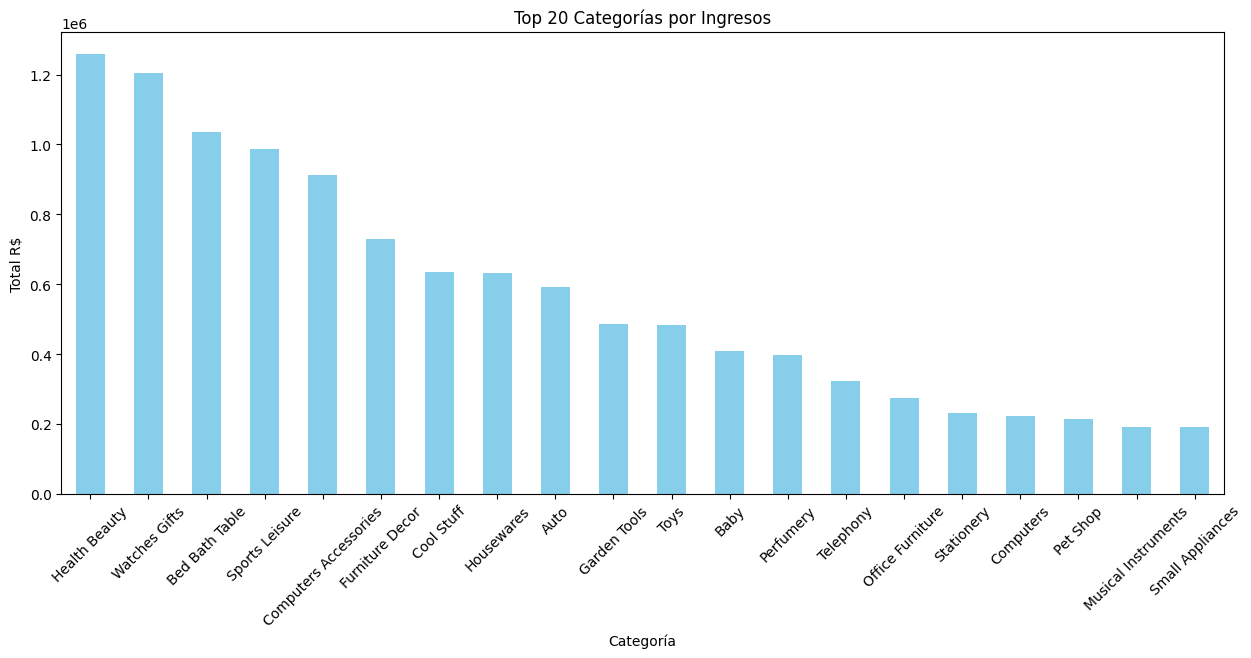

In [60]:
ingresos_categoria_mayor_a_menor.plot(kind='bar', figsize=(15, 6), color='skyblue')
plt.title('Top 20 Categorías por Ingresos')
plt.ylabel('Total R$')
plt.xlabel('Categoría')
plt.xticks(rotation=45)
plt.show()

## Volumen total de productos vendidos por categoria

In [61]:
cantidad_por_categoria= olist_full_table_clean.groupby('product_category_name_english')['order_item_id'].sum()
cantidad_categoria_mayor_a_menor=cantidad_por_categoria.sort_values(ascending=False). head(20)

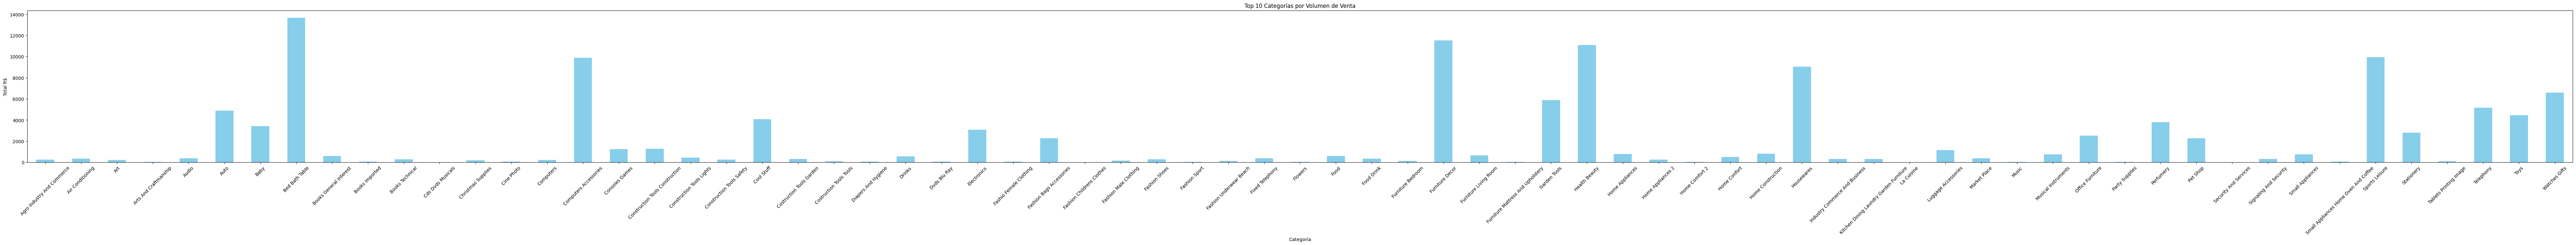

In [62]:
cantidad_por_categoria.plot(kind='bar', figsize=(100, 6), color='skyblue')
plt.title('Top 10 Categorías por Volumen de Venta')
plt.ylabel('Total R$')
plt.xlabel('Categoría')
plt.xticks(rotation=45)
plt.show()

#### Al haber tantas categorias de producto, mejor centrarse en el top por cantidad vendida

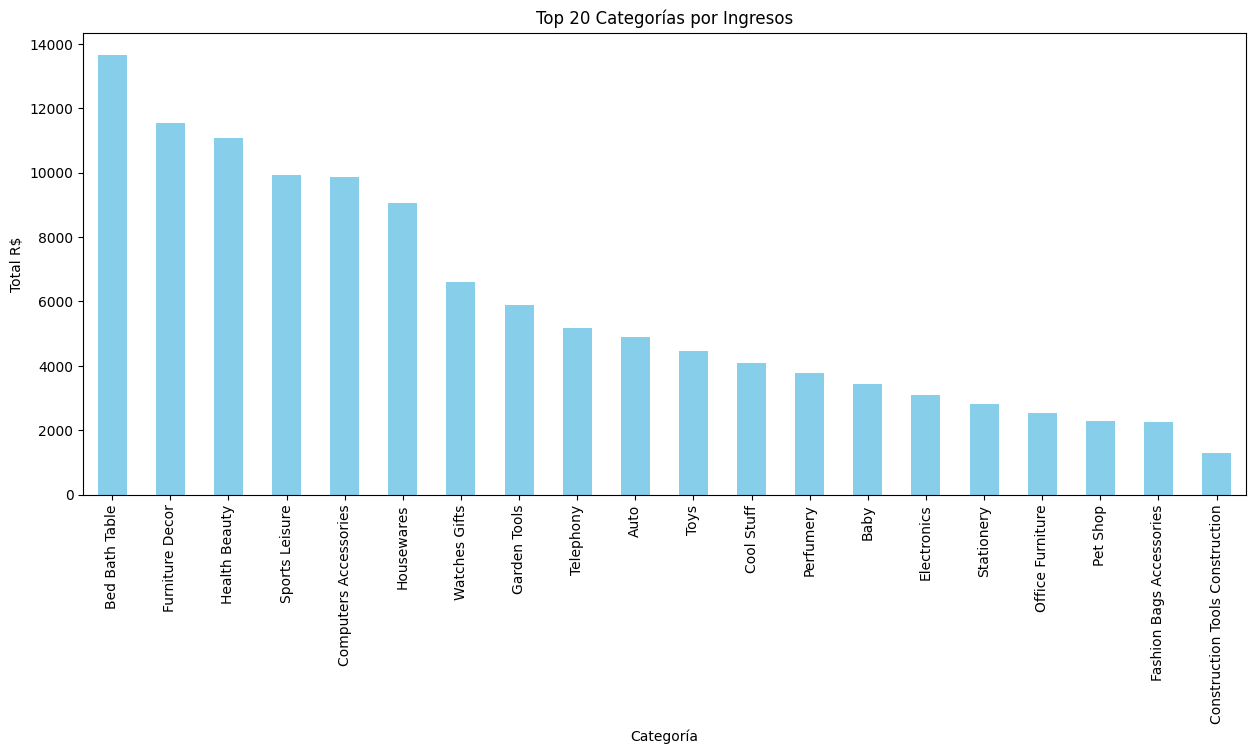

In [63]:
cantidad_categoria_mayor_a_menor.plot(kind='bar', figsize=(15, 6), color='skyblue')
plt.title('Top 20 Categorías por Ingresos')
plt.ylabel('Total R$')
plt.xlabel('Categoría')
plt.xticks(rotation=90)
plt.show()

### Exportamos el documento final unificado con las categorias para su uso en Power BI

In [64]:
olist_full_table_clean.to_parquet('olist_full_table_clean.parquet')